In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = r"P:\snowmelt_stochastic_model\data\raw\era5_chandra_temp_2018_2022.nc"

ds = xr.open_dataset(file_path)

ds

<xarray.Dataset> Size: 227kB
Dimensions:     (valid_time: 1826, latitude: 5, longitude: 5)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 15kB 2018-01-01 ... 2022-12-31
  * latitude    (latitude) float64 40B 33.0 32.75 32.5 32.25 32.0
  * longitude   (longitude) float64 40B 76.5 76.75 77.0 77.25 77.5
    expver      (valid_time) <U4 29kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 183kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-15T10:15 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
temp = ds['t2m'] - 273.15
temp_mean = temp.mean(dim=['latitude', 'longitude'])

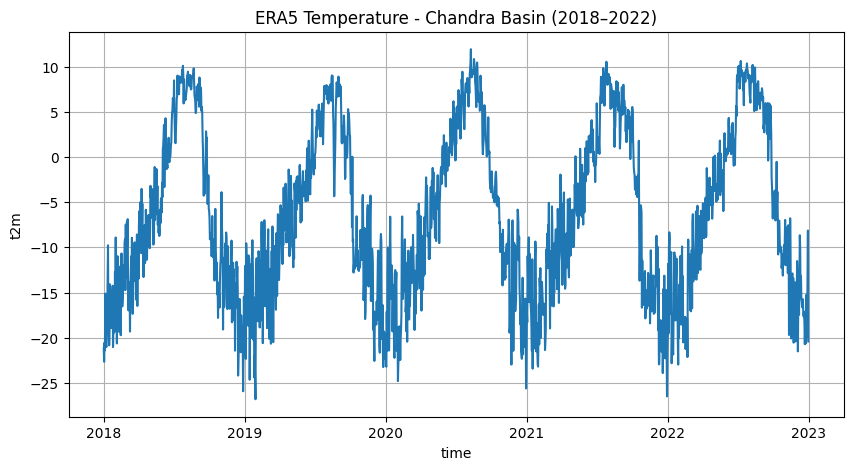

In [4]:
plt.figure(figsize=(10,5))
temp_mean.plot()
plt.title("ERA5 Temperature - Chandra Basin (2018–2022)")
plt.grid()
plt.show()

In [5]:
# =========================
# DEGREE-DAY MODEL
# =========================

DDF = 3.0   # mm/°C/day (initial guess)
T0 = 0.0    # melting threshold

# Compute melt
melt = DDF * (temp_mean - T0)

# No melt below freezing
melt = melt.where(temp_mean > T0, 0)

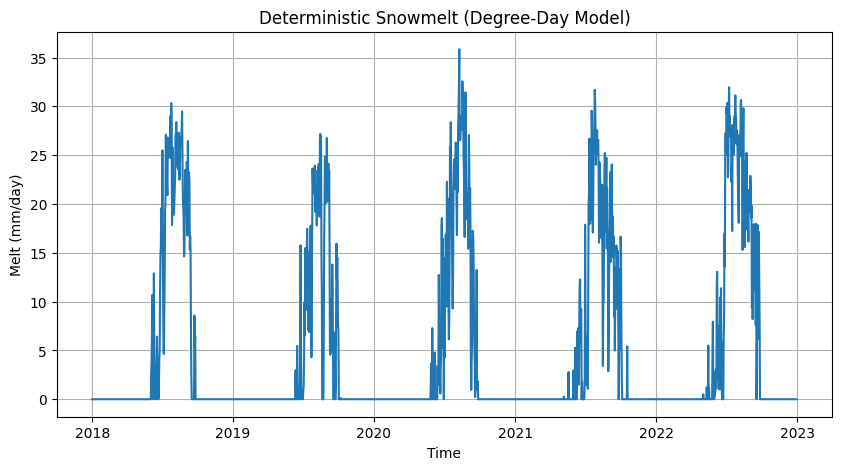

In [6]:
plt.figure(figsize=(10,5))
melt.plot()

plt.title("Deterministic Snowmelt (Degree-Day Model)")
plt.ylabel("Melt (mm/day)")
plt.xlabel("Time")
plt.grid()

plt.show()

In [7]:
# =========================
# STOCHASTIC COMPONENT
# =========================

import numpy as np

# Random noise (standard normal)
epsilon = np.random.normal(0, 1, size=len(melt))

# Convert melt (xarray) to numpy for manipulation
melt_values = melt.values

# Define variability (sigma)
sigma = 0.3 * melt_values   # proportional to melt

# Stochastic melt
melt_stochastic = melt_values + sigma * epsilon

# No negative melt
melt_stochastic = np.maximum(melt_stochastic, 0)

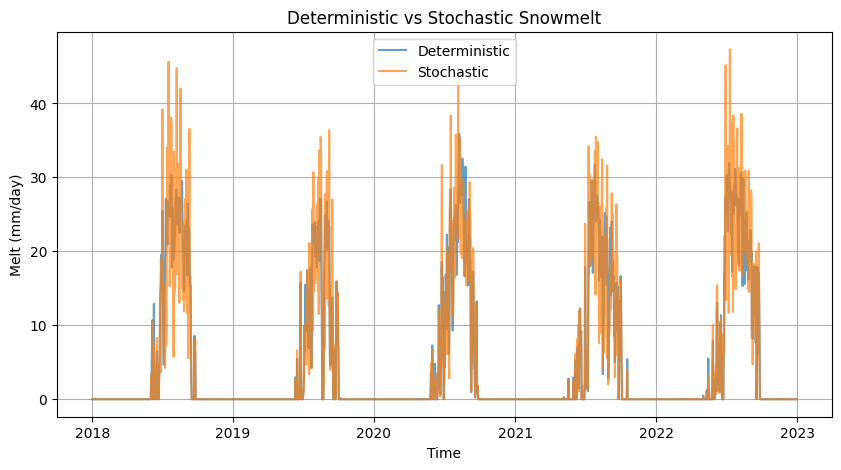

In [9]:
plt.figure(figsize=(10,5))

plt.plot(melt['valid_time'], melt_values, label="Deterministic", alpha=0.7)
plt.plot(melt['valid_time'], melt_stochastic, label="Stochastic", alpha=0.7)

plt.title("Deterministic vs Stochastic Snowmelt")
plt.ylabel("Melt (mm/day)")
plt.xlabel("Time")
plt.legend()
plt.grid()

plt.show()

In [10]:
# =========================
# MONTE CARLO SIMULATION
# =========================

n_simulations = 100

simulations = []

for i in range(n_simulations):
    
    epsilon = np.random.normal(0, 1, size=len(melt_values))
    sigma = 0.3 * melt_values
    
    sim = melt_values + sigma * epsilon
    sim = np.maximum(sim, 0)
    
    simulations.append(sim)

simulations = np.array(simulations)

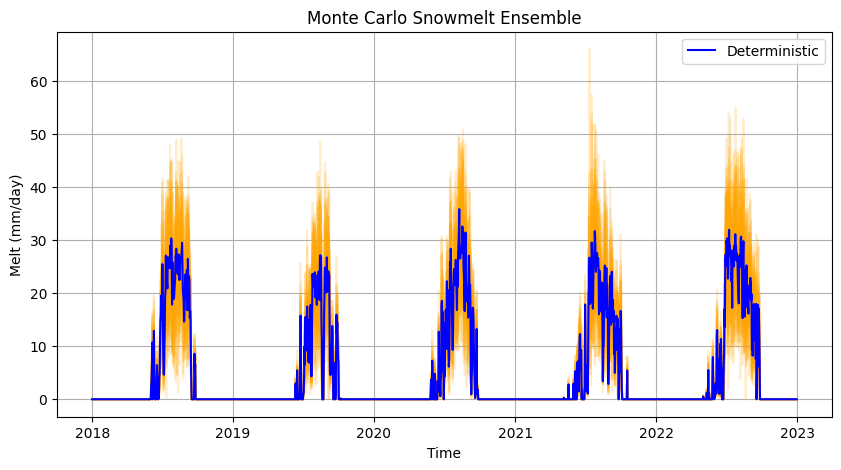

In [11]:
plt.figure(figsize=(10,5))

for i in range(20):  # plot only 20 for clarity
    plt.plot(melt['valid_time'], simulations[i], alpha=0.2, color='orange')

plt.plot(melt['valid_time'], melt_values, color='blue', label='Deterministic')

plt.title("Monte Carlo Snowmelt Ensemble")
plt.ylabel("Melt (mm/day)")
plt.xlabel("Time")
plt.legend()
plt.grid()

plt.show()

In [12]:
# =========================
# STATISTICS FROM ENSEMBLE
# =========================

mean_melt = simulations.mean(axis=0)
std_melt = simulations.std(axis=0)

p10 = np.percentile(simulations, 10, axis=0)
p90 = np.percentile(simulations, 90, axis=0)

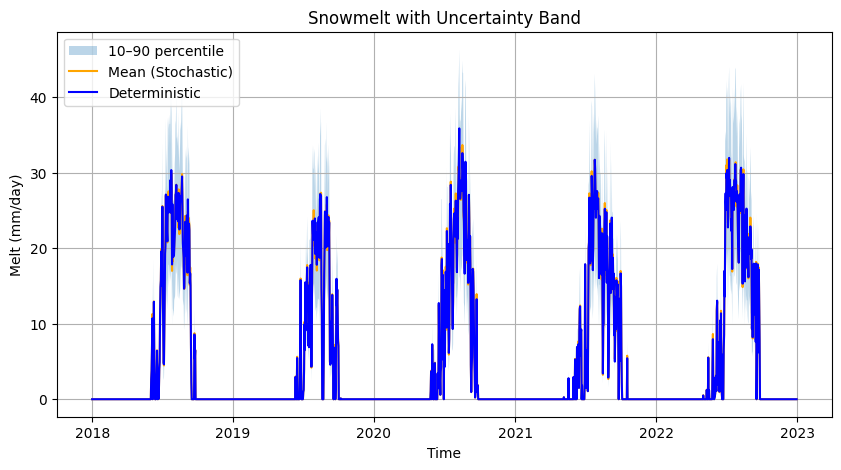

In [13]:
plt.figure(figsize=(10,5))

# Uncertainty band
plt.fill_between(melt['valid_time'], p10, p90, alpha=0.3, label="10–90 percentile")

# Mean
plt.plot(melt['valid_time'], mean_melt, label="Mean (Stochastic)", color='orange')

# Deterministic
plt.plot(melt['valid_time'], melt_values, label="Deterministic", color='blue')

plt.title("Snowmelt with Uncertainty Band")
plt.ylabel("Melt (mm/day)")
plt.xlabel("Time")
plt.legend()
plt.grid()0.

plt.show()